<a href="https://colab.research.google.com/github/Chandu1722/ML/blob/main/Kaggle/FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
zalando_research_fashionmnist_path = kagglehub.dataset_download('zalando-research/fashionmnist')

print('Data source import complete.')


Using Colab cache for faster access to the 'fashionmnist' dataset.
Data source import complete.


In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/fashionmnist/fashion-mnist_test.csv
/kaggle/input/fashionmnist/fashion-mnist_train.csv
/kaggle/input/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/fashionmnist/train-images-idx3-ubyte


In [16]:
import tensorflow as tf
from tensorflow.keras import models,layers
from sklearn.model_selection import train_test_split

In [17]:
train=pd.read_csv('/kaggle/input/fashionmnist/fashion-mnist_train.csv')
train.shape

(60000, 785)

In [18]:
X=train.drop('label',axis=1)
y=train['label']

In [19]:
X=X/255.0

In [20]:
x_reshape=X.values.reshape(-1,28,28,1)
y_cat=tf.keras.utils.to_categorical(y,num_classes=10)

In [21]:
x_train,x_val,y_train,y_val=train_test_split(x_reshape,y_cat,test_size=0.2,random_state=42)

In [22]:
model=models.Sequential([
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [24]:
history=model.fit(x_train,y_train,epochs=10,validation_data=(x_val,y_val))

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 111s 72ms/step - accuracy: 0.6652 - loss: 0.9096 - val_accuracy: 0.8413 - val_loss: 0.4210
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 108s 72ms/step - accuracy: 0.8515 - loss: 0.4199 - val_accuracy: 0.8852 - val_loss: 0.3053
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 107s 71ms/step - accuracy: 0.8811 - loss: 0.3406 - val_accuracy: 0.8975 - val_loss: 0.2825
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 137s 68ms/step - accuracy: 0.8954 - loss: 0.2961 - val_accuracy: 0.9015 - val_loss: 0.2694
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 107s 71ms/step - accuracy: 0.9090 - loss: 0.2614 - val_accuracy: 0.9053 - val_loss: 0.2545
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 137s 68ms/step - accuracy: 0.9145 - loss: 0.2438 - val_accuracy: 0.9132 - val_loss: 0.2404
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 102s 68ms/step - accuracy: 0.9218 - loss: 0.2252 - val_accuracy: 0.9122 - val_loss: 0.2429
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 102s 68ms/step - accuracy: 

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9198 - loss: 0.2246

Validation Loss: 0.2346085160970688
Validation Accuracy: 91.98%


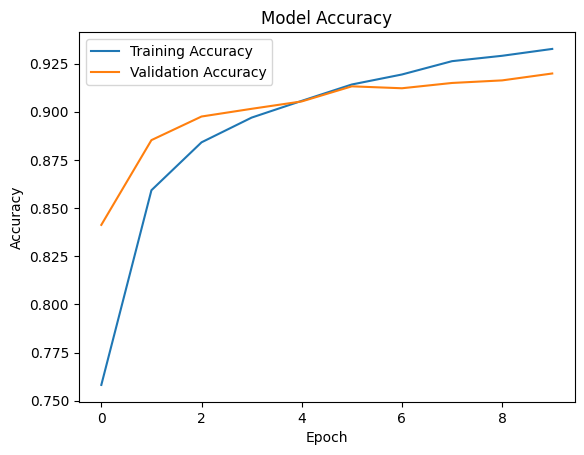

In [25]:
val_loss, val_acc = model.evaluate(x_val, y_val)
print(f"\nValidation Loss: {val_loss}")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()